# 18 Mixtura de expertos (MoE)

**[Capa de mixtura de expertos (2017)](https://arxiv.org/abs/1701.06538):** un conjunto de $n$ expertos (redes neuronales) $\boldsymbol{E} =\{E_1, \cdots, E_n\}$, y una red neuronal puerta $G$ cuya salida es un vector $n$-dimensional disperso.
$$
\operatorname{MoE}(\boldsymbol{x},E,G) = \sum_{k=1}^n G(\boldsymbol{x})_k E_k(\boldsymbol{x}) 
$$

<div><table align="center"><tr><td style="border: none;"><img src="MoE.png" width="600" /></td></tr></table></div>

La PWFFN del Transformer original se sustituye por una mixtura de expertos donde cada experto es una PWFFN.

<p style="page-break-after:always;"></p>

**Redes neuronales puerta:**

* Puerta $\operatorname{Softmax}$ (densa)
$$
G(\boldsymbol{x}) = \operatorname{Softmax}(\boldsymbol{x}W^G)
$$

* Puerta mejores-k con ruido (dispersa):
$$
G(\boldsymbol{x}) = \operatorname{Softmax}(\operatorname{TopK}(\boldsymbol{x}W^G + \epsilon))
$$

$\qquad$ donde $\epsilon \sim {\cal N}(0,\operatorname{Softplus}(\boldsymbol{x}W^{\epsilon}))$ contribuye al reparto equilibrado de muestras entre expertos.

[$\operatorname{Softplus}$](https://docs.pytorch.org/docs/stable/generated/torch.nn.Softplus.html): aproximación suave de la función $\operatorname{ReLU}$

$$
\operatorname{Softplus}(x,\beta=1) = \log(1 + e^x)
$$

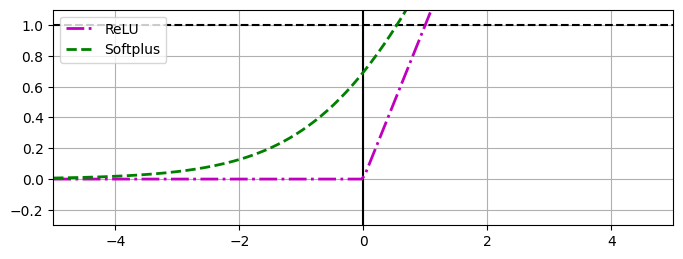

In [1]:
import torch; import matplotlib.pyplot as plt; a = torch.linspace(-5, 5, 200)
plt.figure(figsize=(8,2.8)); plt.grid(True); plt.axis([-5, 5, -0.3, 1.1]); 
plt.plot([-5, 5], [-1, -1], 'k-'); plt.plot([-5, 5], [1, 1], 'k--'); plt.plot([0, 0], [-1.1, 1.1], 'k-')
plt.plot(a, torch.maximum(a, torch.zeros_like(a)), "m-.", linewidth=2, label="ReLU"); 
softplus = torch.nn.Softplus(); plt.plot(a, softplus(a), "g--", lw=2, label="Softplus");plt.legend(loc="upper left");